In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

dataset = pd.read_csv("../dataset/featured_dataset.csv")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539226 entries, 0 to 539225
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               539226 non-null  int64  
 1   make               539226 non-null  object 
 2   model              539226 non-null  object 
 3   trim               539226 non-null  object 
 4   body               536458 non-null  object 
 5   transmission       476694 non-null  object 
 6   vin                539226 non-null  object 
 7   state              539226 non-null  object 
 8   condition          539226 non-null  float64
 9   odometer           539226 non-null  float64
 10  color              539226 non-null  object 
 11  interior           539226 non-null  object 
 12  seller             539226 non-null  object 
 13  mmr                539226 non-null  float64
 14  sellingprice       539226 non-null  float64
 15  saledate           539226 non-null  object 
 16  sa

In [109]:
dataset.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,sale_year,vehicle_age,mmr_vs_sp,mmr_vs_sp_percent
0,2015,kia,sorento,lx,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,1000.0,4.88
1,2015,kia,sorento,lx,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,700.0,3.37
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00+00:00,2015,1,-1900.0,-5.96
3,2015,volvo,s60,t5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00+00:00,2015,0,250.0,0.91
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00+00:00,2014,0,1000.0,1.52


In [110]:
#1. Total revenue through years

dataset["sellingprice"].sum()

np.float64(7371675733.0)

In [111]:
#2. Total units sold through years.

dataset["vin"].size

539226

In [112]:
#3. Top 10 highest units sold company (all time).

top_10_vehicles = (dataset.groupby(["make"])["vin"]
                   .agg("count")
                   .sort_values(ascending = False)
                   .reset_index(name = "unit_sold")
                   .head(10))
top_10_vehicles

,make,unit_sold
0,ford,92311
1,chevrolet,59562
2,nissan,53297
3,toyota,39419
4,dodge,30460
5,honda,26966
6,hyundai,21578
7,bmw,20217
8,kia,17890
9,chrysler,17237


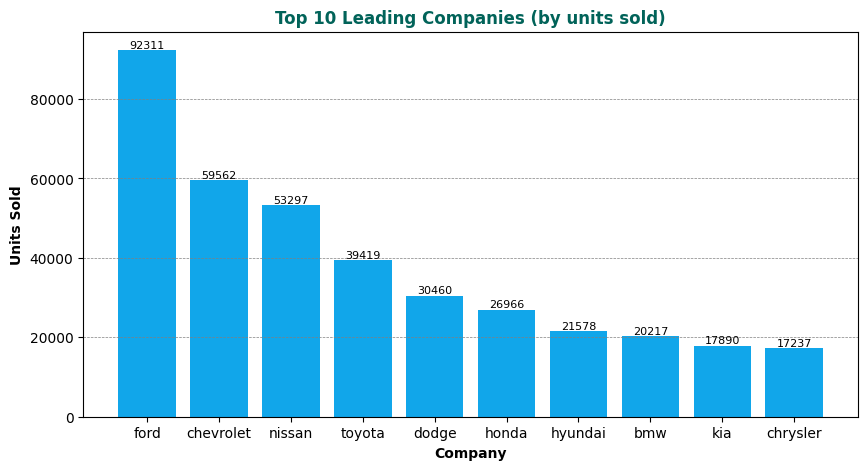

In [113]:
# plotting graph

x_axis = top_10_vehicles["make"]
y_axis = top_10_vehicles["unit_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis, color = "#11a6eaff")

plt.bar_label(bars, fontsize = 8)
plt.grid(axis = "y" , linestyle = "--", linewidth = 0.5, color = "grey")

plt.title("Top 10 Leading Companies (by units sold)", loc = "center", fontweight = "bold", color = "#016359")
plt.xlabel("Company", loc = "center", fontweight = "bold")
plt.ylabel("Units Sold", fontweight = "bold")

plt.savefig("../charts/top_10_companies_by_units_sold")
plt.show()

In [114]:
#4. Top 10 unit sold states (all time).

top_10_states = (dataset.groupby(["state"])["vin"]
                 .agg("count")
                 .sort_values(ascending = False)
                 .reset_index(name = "units_sold")
                 .head(10))
top_10_states

,state,units_sold
0,fl,80362
1,ca,70061
2,pa,52431
3,tx,44271
4,ga,33281
5,nj,27115
6,il,22987
7,oh,20789
8,nc,20747
9,tn,19875


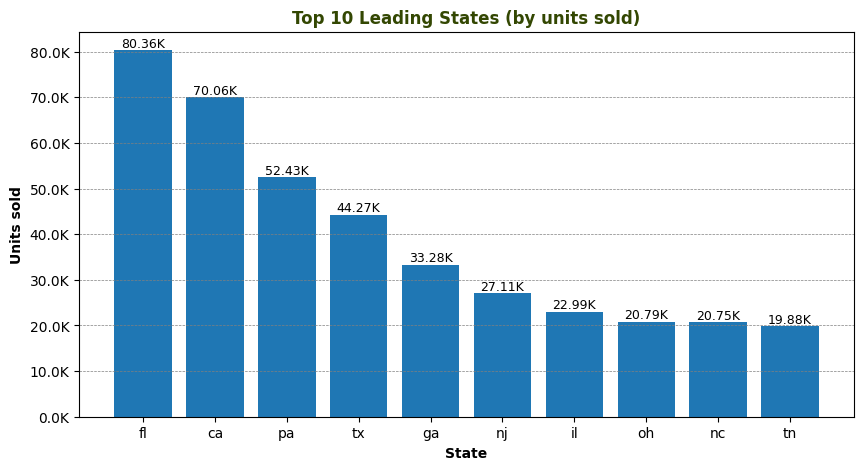

In [115]:
# plotting graph

x_axis = top_10_states["state"]
y_axis = top_10_states["units_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.grid(axis = "y", linewidth = 0.5, color = "grey", linestyle = "--")

plt.title("Top 10 Leading States (by units sold)", fontweight = "bold", color = "#334702")
plt.xlabel("State", fontweight = "bold")
plt.ylabel("Units sold", fontweight = "bold")

plt.bar_label(bars, 
              labels = [f"{x/1000:.2f}K" for x in bars.datavalues],
              fontsize = 9)

plt.savefig("../charts/top_10_states_by_units_sold")
plt.show()

In [116]:
#5. Median age of vehicle (all time).

dataset["vehicle_age"].agg("median")

np.float64(3.0)

In [117]:
#6. Highest units sold vehicle [make, body, trim] (all time).

top_10_make_model = (dataset.groupby(["make", "model"])["vin"]
.agg("count")
.sort_values(ascending = False)
.reset_index(name = "unit_sold")
.head(10)
)

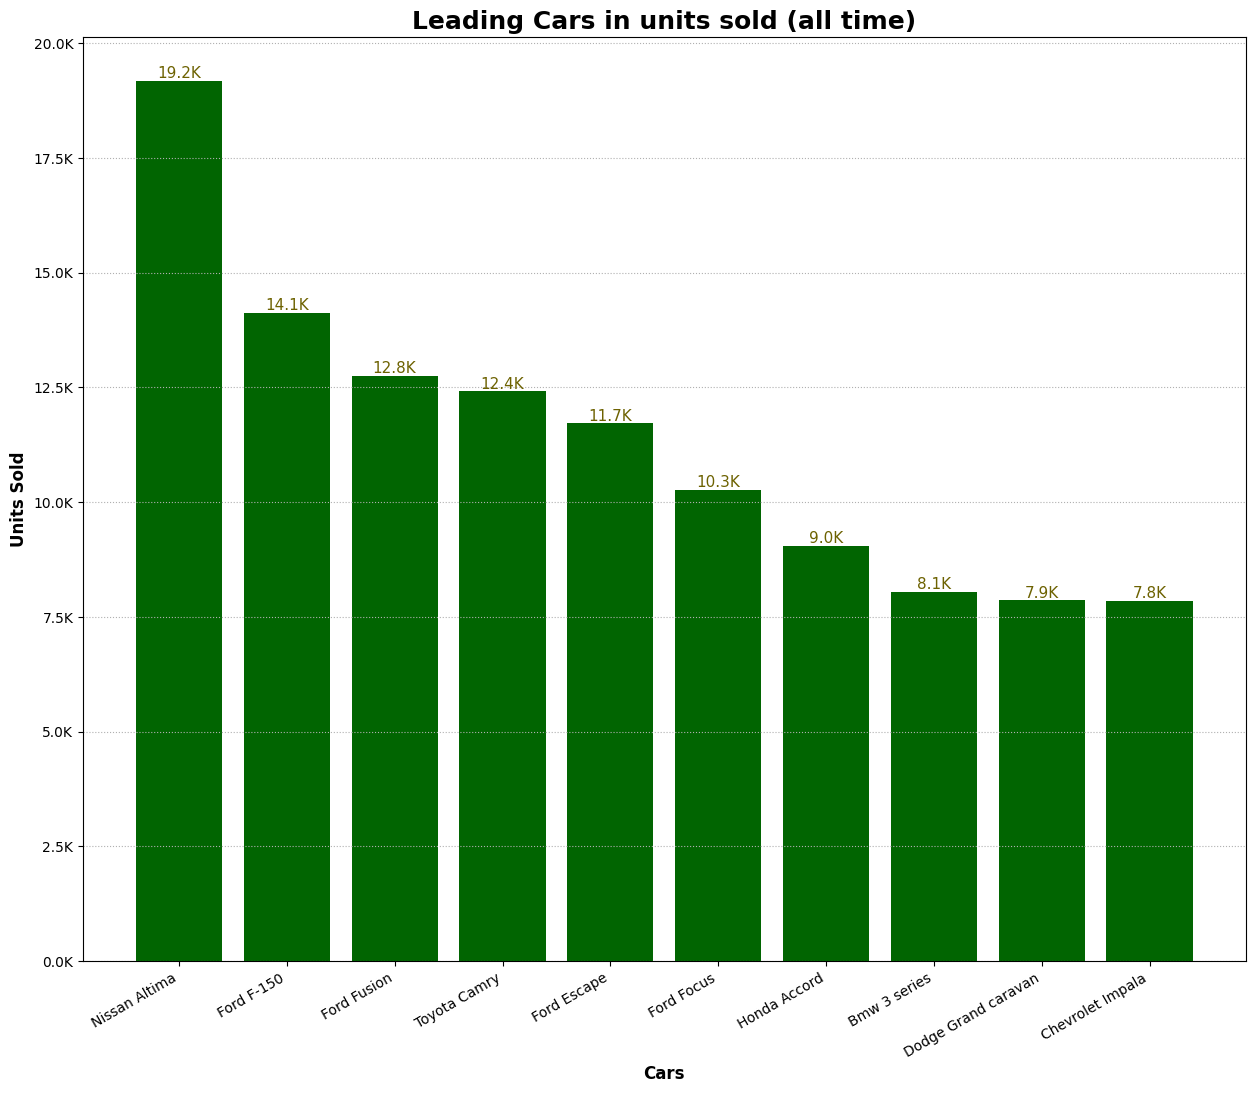

In [118]:
#6. Graph

x_axis = top_10_make_model["make"].str.capitalize() + " " + top_10_make_model["model"].str.capitalize()
y_axis = top_10_make_model["unit_sold"]

plt.figure(figsize = (15, 12))

bars = plt.bar(x_axis, y_axis, color = "#016501")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.bar_label(bars,
              labels = [f"{x/1000:.1f}K" for x in bars.datavalues],
              color = "#6D6201",
              fontsize = 11)

plt.xticks(rotation = 30, ha = "right")
plt.grid(axis = "y", linewidth = 0.8, linestyle = ":")

plt.title("Leading Cars in units sold (all time)", fontsize = 18, fontweight = "bold")
plt.xlabel("Cars", fontsize = 12, fontweight = "bold")
plt.ylabel("Units Sold", fontsize = 12, fontweight = "bold")

plt.savefig("../charts/top_10_cars_by_units_sold.png")
plt.show()

In [119]:
#7. Past 10 years year wise, leading company in units sold.

year_group = (dataset.groupby(["year", "make"])["vin"]
              .count()
              .reset_index(name = "units"))

year_group


,year,make,units
0,1984,chevrolet,1
1,1985,chevrolet,2
2,1986,chevrolet,1
3,1987,mercedes,1
4,1989,chevrolet,2
...,...,...,...
893,2015,smart,3
894,2015,subaru,235
895,2015,toyota,236
896,2015,volkswagen,63


In [120]:
past_years_top_company = year_group.loc[year_group.groupby(["year"])["units"].idxmax()]
past_10_years_top_company = year_group.loc[year_group.groupby(["year"])["units"].idxmax()].tail(10)

In [121]:
past_10_years_top_company["make"].unique()

array(['ford', 'chevrolet', 'nissan', 'kia'], dtype=object)

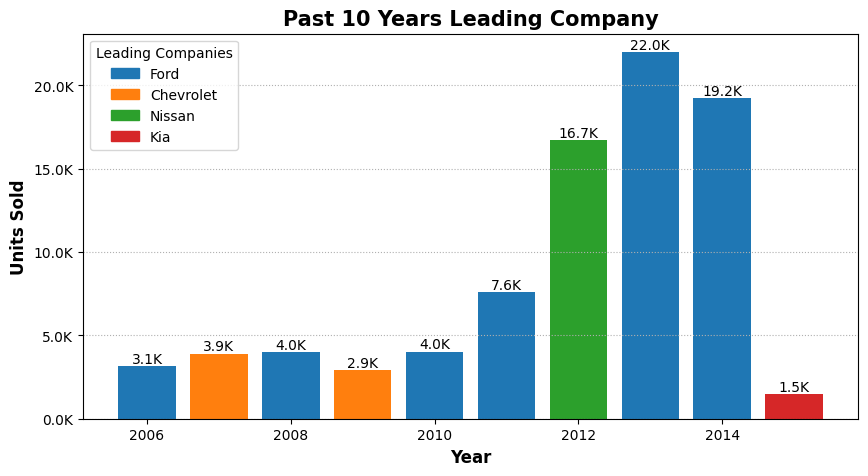

In [122]:
x_axis = past_10_years_top_company["year"]
y_axis = past_10_years_top_company["units"]

unique_companies = past_10_years_top_company["make"].unique()

# Alloting colour to companies
colors = plt.cm.tab10(range(len(unique_companies)))
color_map = dict(zip(unique_companies, colors))
color_bars = past_10_years_top_company["make"].map(color_map)

# Defining structure of graph
plt.figure(figsize = (10, 5))
bars = plt.bar(x_axis, y_axis, color = color_bars)
plt.grid(axis = "y", linestyle = ":", linewidth = 0.8)
plt.bar_label(bars,
              labels = [f"{x/1000:.1f}K" for x in bars.datavalues])

# Formatting
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

# Contents of legend
legend_items = [Patch(color = color_map[company], label = company.capitalize()) for company in unique_companies]

plt.legend(handles = legend_items, title = "Leading Companies")

# Titles
plt.title("Past 10 Years Leading Company", fontsize = 15, fontweight = "bold")
plt.xlabel("Year", fontsize = 12, fontweight = "bold")
plt.ylabel("Units Sold", fontsize = 12, fontweight = "bold")

plt.savefig("../charts/past_10_year_leading_companies.png")
plt.show()

In [123]:
#8. Past year (all time) leading companies distribution.

leading_company_distribution = past_years_top_company["make"].value_counts().reset_index(name = "frequency")

leading_company_distribution["percent_share"] = round(((leading_company_distribution["frequency"] /
                                                  leading_company_distribution["frequency"].sum())* 100)
                                                  , 2)

leading_company_distribution

,make,frequency,percent_share
0,ford,13,41.94
1,chevrolet,7,22.58
2,toyota,5,16.13
3,honda,3,9.68
4,mercedes,1,3.23
5,nissan,1,3.23
6,kia,1,3.23


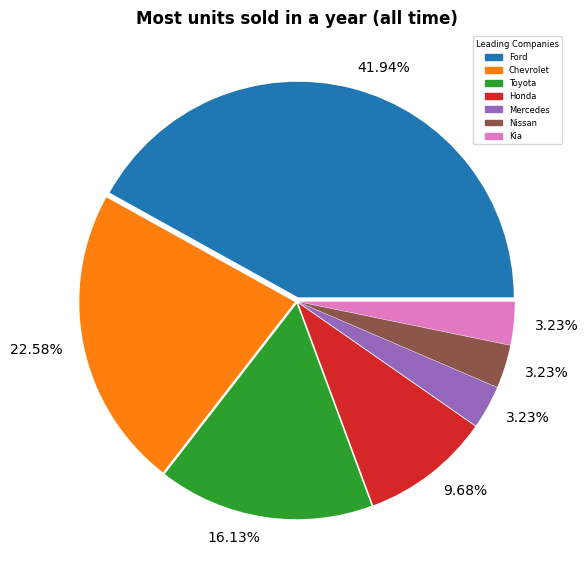

In [124]:
values = leading_company_distribution["frequency"]
companies_percent = leading_company_distribution["percent_share"].astype('string') + "%"

pie_colors = plt.cm.tab10(range(len(leading_company_distribution["make"])))
color_map = dict(zip(leading_company_distribution["make"], pie_colors))
color_parts = leading_company_distribution["make"].map(color_map)


plt.figure(figsize = (7, 7))
plt.pie(values,
        labels = companies_percent,
        colors = pie_colors,
        startangle = 0,
        explode = [0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
        )

legend_items = [Patch(color = color_map[company], label = company.capitalize()) for company in leading_company_distribution["make"]]

plt.legend(handles = legend_items,
           title = "Leading Companies",
           fontsize = 6,
           title_fontsize = 6)


plt.title("Most units sold in a year (all time)", fontweight = "bold", fontsize = 12)
plt.savefig("../charts/most_sold_companies_all_time.png")
plt.show()

In [125]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539226 entries, 0 to 539225
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               539226 non-null  int64  
 1   make               539226 non-null  object 
 2   model              539226 non-null  object 
 3   trim               539226 non-null  object 
 4   body               536458 non-null  object 
 5   transmission       476694 non-null  object 
 6   vin                539226 non-null  object 
 7   state              539226 non-null  object 
 8   condition          539226 non-null  float64
 9   odometer           539226 non-null  float64
 10  color              539226 non-null  object 
 11  interior           539226 non-null  object 
 12  seller             539226 non-null  object 
 13  mmr                539226 non-null  float64
 14  sellingprice       539226 non-null  float64
 15  saledate           539226 non-null  object 
 16  sa

In [126]:
# 9. Condition of vehicles with respect to Age.

age_by_condition = (dataset[dataset["vehicle_age"] >= 0]
                    .groupby("vehicle_age")["condition"]
                    .agg("median")
                    .reset_index(name = "condition"))

age_by_vehicle = (dataset[dataset["vehicle_age"] >= 0]
                  .groupby(["vehicle_age"])["vin"]
                  .agg('count')
                  .reset_index(name = "vehicle_count")
                  )

revenue_by_age = (dataset.groupby(["vehicle_age"])["sellingprice"]
                 .sum()
                 .reset_index(name = "revenue"))

mmr_vs_sp_by_age = (dataset.groupby(["vehicle_age"])["mmr_vs_sp_percent"]
                    .agg('median')
                    .reset_index(name = "change"))

mmr_vs_sp_by_age

,vehicle_age,change
0,-1,-0.970
1,0,-0.650
2,1,-0.350
3,2,-0.310
4,3,-0.270
5,4,-0.300
6,5,-0.340
7,6,-0.380
8,7,-0.440
9,8,-0.880


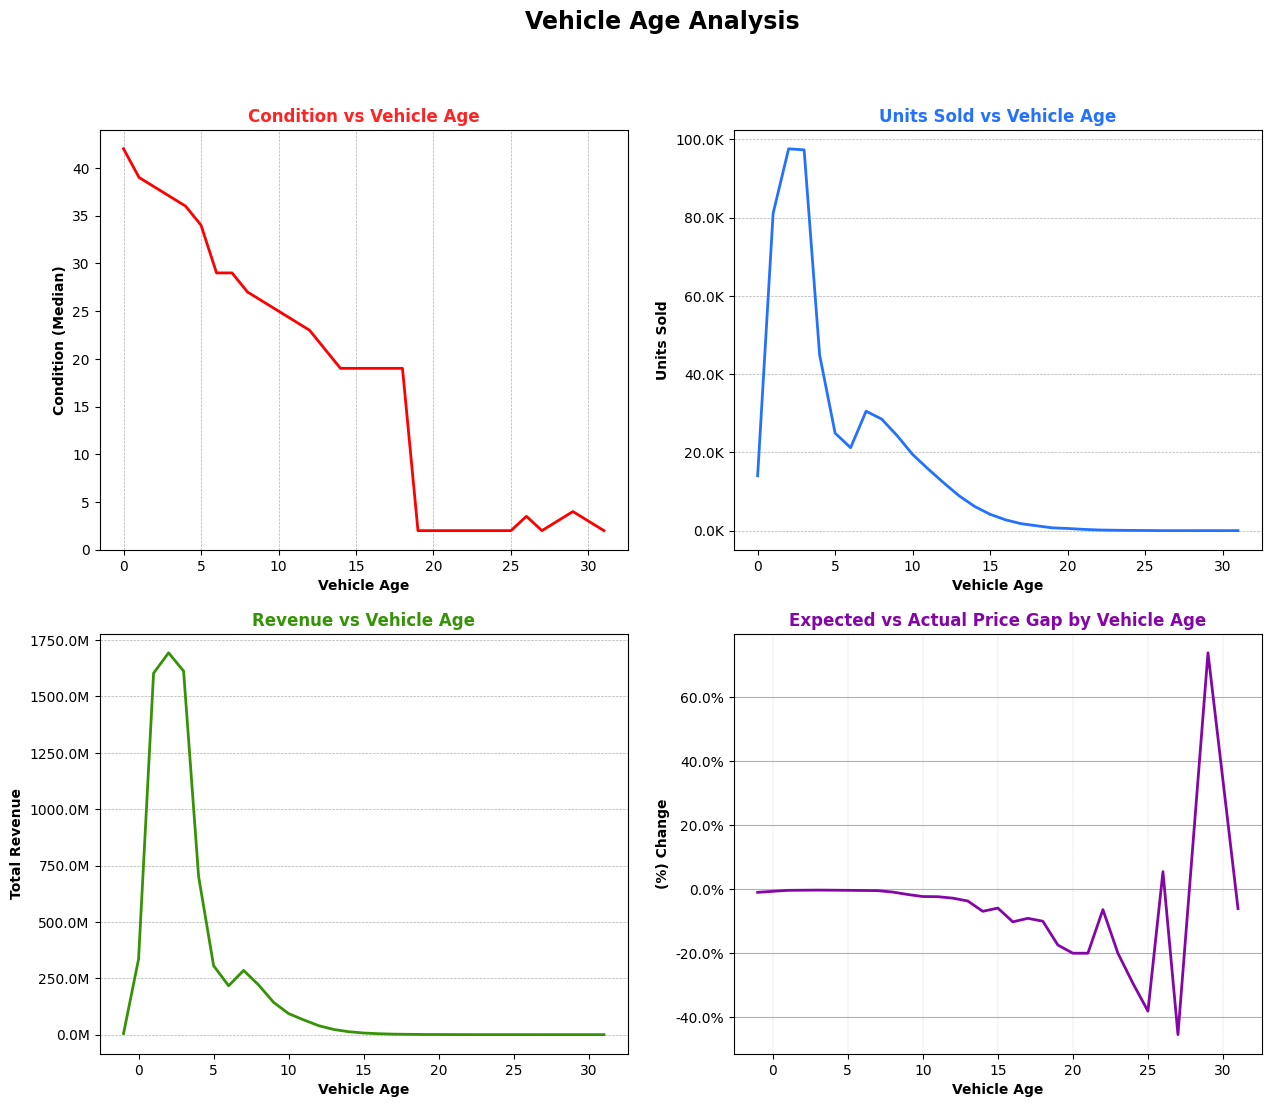

In [127]:
# graph

plt.figure(figsize = (15, 12))

# Graph - 1
x_axis = age_by_condition["vehicle_age"]
y_axis = age_by_condition["condition"]

plt.subplot(2, 2, 1)
line = plt.plot(x_axis, y_axis, color = "red", linewidth = 2)

plt.grid(axis = "x", linewidth = 0.5, color = "#B2B1B1", linestyle = "--")

plt.xlabel("Vehicle Age", fontweight = "bold")
plt.ylabel("Condition (Median)", fontweight = "bold")
plt.title("Condition vs Vehicle Age", fontweight = "bold", color = "#FF2424")

# Graph - 2
x_axis = age_by_vehicle["vehicle_age"]
y_axis = age_by_vehicle["vehicle_count"]

plt.subplot(2, 2, 2)
plt.plot(x_axis, y_axis, color = "#2471FF", linewidth = 2)

plt.grid(axis = "y", linewidth = 0.5, linestyle = "--", color = "#B2B1B1")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.xlabel("Vehicle Age", fontweight = "bold")
plt.ylabel("Units Sold", fontweight = "bold")
plt.title("Units Sold vs Vehicle Age", fontweight = "bold", color = "#2471FF")

# Graph - 3

plt.subplot(2, 2, 3)
x_axis = revenue_by_age["vehicle_age"]
y_axis = revenue_by_age["revenue"]

line = plt.plot(x_axis, y_axis, color = "#369308", linewidth = 2)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000000:.1f}M")
)

plt.grid(axis = "y", linewidth = 0.5, linestyle = "--")

plt.xlabel("Vehicle Age", fontweight = "bold")
plt.ylabel("Total Revenue", fontweight = "bold")
plt.title("Revenue vs Vehicle Age", fontweight = "bold", color = "#369308")

# Graph - 4

plt.subplot(2, 2, 4)

x_axis = mmr_vs_sp_by_age["vehicle_age"]
y_axis = mmr_vs_sp_by_age["change"]

plt.plot(x_axis, y_axis, color = "#8406A7", linewidth = 2)

plt.grid(axis = "y", linewidth = 0.8)
plt.grid(axis = "x", linewidth = 0.2, linestyle = "--")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x}%")
)

plt.xlabel("Vehicle Age", fontweight = "bold")
plt.ylabel("(%) Change", fontweight = "bold")
plt.title("Expected vs Actual Price Gap by Vehicle Age", fontweight = "bold", color = "#8406A7")


plt.suptitle("Vehicle Age Analysis", fontsize = 17, fontweight = "bold")

plt.savefig("../charts/vehicle_age_analysis.png")
plt.show()

In [128]:
top_10_body = (dataset["body"]
              .value_counts()
              .sort_values(ascending = False)
              .reset_index(name = "units_sold")
              .head(10))

body_make_group = (dataset.groupby(["body"])["make"]
 .value_counts()
 .sort_values(ascending = False)
 .reset_index(name = "units_sold"))

leading = body_make_group.loc[body_make_group.groupby(["body"])["units_sold"].idxmax()]

leading = leading.loc[leading["units_sold"].sort_values(ascending = False).index]

top_body_make_color_refer = leading[leading["body"].isin(top_10_body["body"])][["body", "make"]]

top_body_make_color_refer



,body,make
0,sedan,nissan
1,suv,ford
14,supercrew,ford
17,minivan,dodge
19,g sedan,infiniti
23,crew cab,chevrolet
28,hatchback,ford
43,coupe,ford
45,wagon,kia
59,convertible,ford


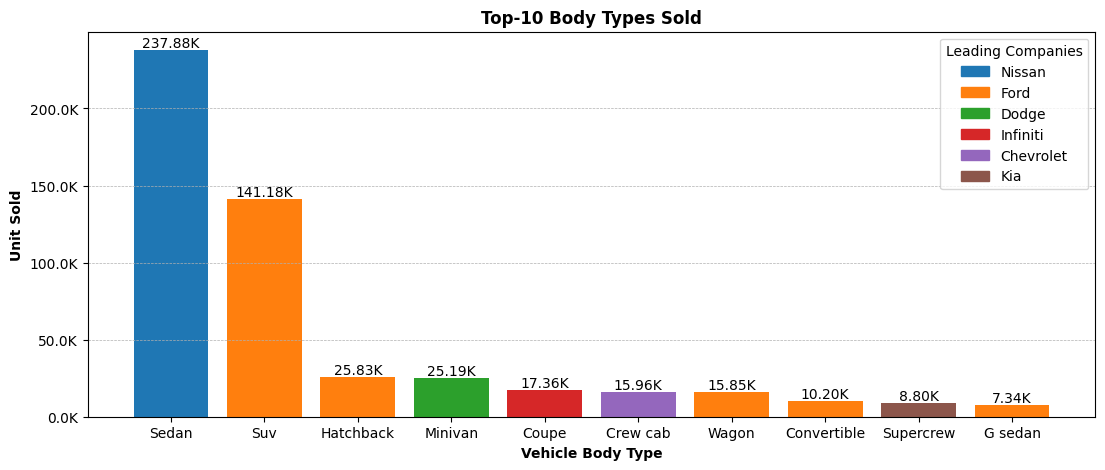

In [129]:
# Graph

plt.figure(figsize = (13, 5))

x_axis = top_10_body["body"].str.capitalize()
y_axis = top_10_body["units_sold"]

companies = top_body_make_color_refer["make"].unique()

# Color Allotment
colors = plt.cm.tab10(range(len(companies)))
color_map = dict(zip(companies, colors))
bar_colors = top_body_make_color_refer["make"].map(color_map)

# Plotting
bars = plt.bar(x_axis, y_axis, color = bar_colors)
plt.bar_label(bars, labels = [f"{x/1000:.2f}K" for x in bars.datavalues])

# Formatting
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000}K")
)

plt.grid(axis = "y", linestyle = "--", linewidth = 0.5)

# Legend
legend_items = [
    Patch(color = color_map[company], label = company.capitalize())
    for company in color_map
]

plt.legend(handles = legend_items, title = "Leading Companies")

# labels
plt.xlabel("Vehicle Body Type", fontweight = "bold")
plt.ylabel("Unit Sold", fontweight = "bold")
plt.title("Top-10 Body Types Sold", fontweight = "bold", fontsize = 12)

plt.savefig("../charts/top_10_leading_body_types.png")
plt.show()


In [130]:
# 14. Top 10 Sellers by units sold.

top_10_seller = (dataset.groupby(["seller"])["vin"]
                 .agg('count')
                 .reset_index(name = "units_sold")
                 .sort_values(ascending = False, by = ["units_sold"])
                 .head(10)
                )

# Top State by sellers
seller_state_group = (dataset.groupby(["seller", "state"])["vin"]
                      .agg('count')
                      .reset_index(name = "units_sold")
                      .sort_values(ascending = False, by = "units_sold")
                      )

leading_state_by_seller = seller_state_group.loc[seller_state_group.groupby(["seller"])["units_sold"].idxmax()]
leading_state_by_top_seller = (leading_state_by_seller[leading_state_by_seller["seller"].isin(top_10_seller["seller"])]
                               .set_index(["seller"])
                               .reindex(top_10_seller["seller"])
                               .reset_index())

leading_state_by_top_seller



,seller,state,units_sold
0,nissan-infiniti lt,fl,3629
1,ford motor credit company llc,il,3179
2,the hertz corporation,ca,2300
3,santander consumer,tx,2511
4,avis corporation,tx,2487
5,nissan infiniti lt,ca,2751
6,wells fargo dealer services,ga,1010
7,enterprise veh exchange/rental,fl,1261
8,hyundai motor finance,fl,1586
9,tdaf remarketing,fl,2220


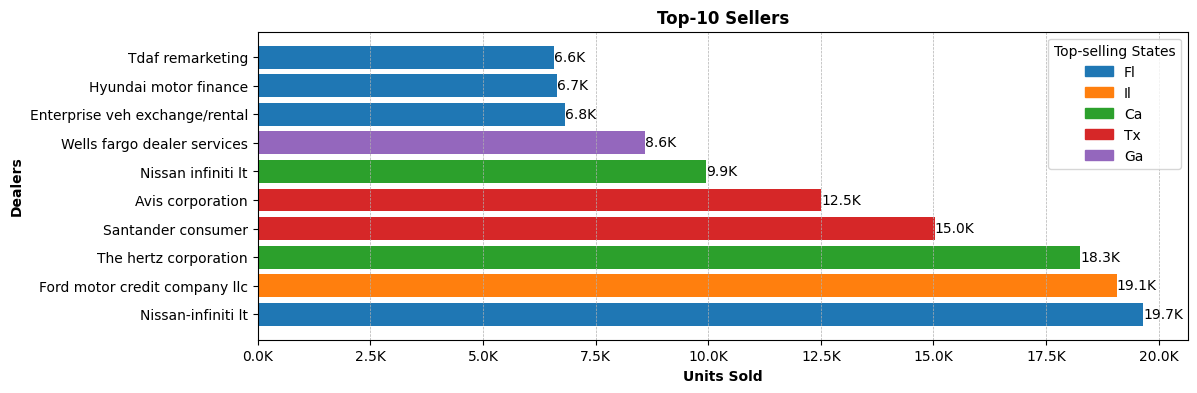

In [131]:
# Graph

plt.figure(figsize = (12, 4))

# Varialbles 
y_axis = top_10_seller["seller"].str.capitalize()
x_axis = top_10_seller["units_sold"]

states = leading_state_by_top_seller["state"].unique()

# Color allotment
colors = plt.cm.tab10(range(len(states)))
color_map = dict(zip(states, colors))
bar_colors = leading_state_by_top_seller["state"].map(color_map)

bars = plt.barh(y_axis, x_axis, color = bar_colors)

# Formatting
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.bar_label(bars, labels = [f"{x/1000:.1f}K" for x in bars.datavalues])

plt.grid(axis = "x", linewidth = 0.5, linestyle = "--")

legend_items = [Patch(color = color_map[state], label = state.capitalize()) for state in color_map]

plt.legend(handles = legend_items, title = "Top-selling States")

# Labels
plt.xlabel("Units Sold", fontweight = "bold")
plt.ylabel("Dealers", fontweight = "bold")
plt.title("Top-10 Sellers", fontweight = "bold")

plt.savefig("../charts/top_10_sellers.png", bbox_inches = "tight")
plt.show()

In [132]:
# 15. Top 10 Sellers by units sold (+) top-selling compaies.

# Top brand by sellers
seller_make_group = (dataset.groupby(["seller", "make"])["vin"]
                     .agg('count')
                     .reset_index(name = "units_sold"))

seller_top_make = seller_make_group.loc[seller_make_group.groupby(["seller"])["units_sold"].idxmax()]

seller_top_make = (seller_top_make[seller_top_make["seller"].isin(top_10_seller["seller"])]
                   .set_index("seller")
                   .reindex(top_10_seller["seller"])
                   .reset_index())

seller_top_make

,seller,make,units_sold
0,nissan-infiniti lt,nissan,19656
1,ford motor credit company llc,ford,17247
2,the hertz corporation,chevrolet,4538
3,santander consumer,chevrolet,2414
4,avis corporation,chevrolet,1914
5,nissan infiniti lt,infiniti,9944
6,wells fargo dealer services,chevrolet,1375
7,enterprise veh exchange/rental,chevrolet,1459
8,hyundai motor finance,hyundai,6322
9,tdaf remarketing,ford,1046


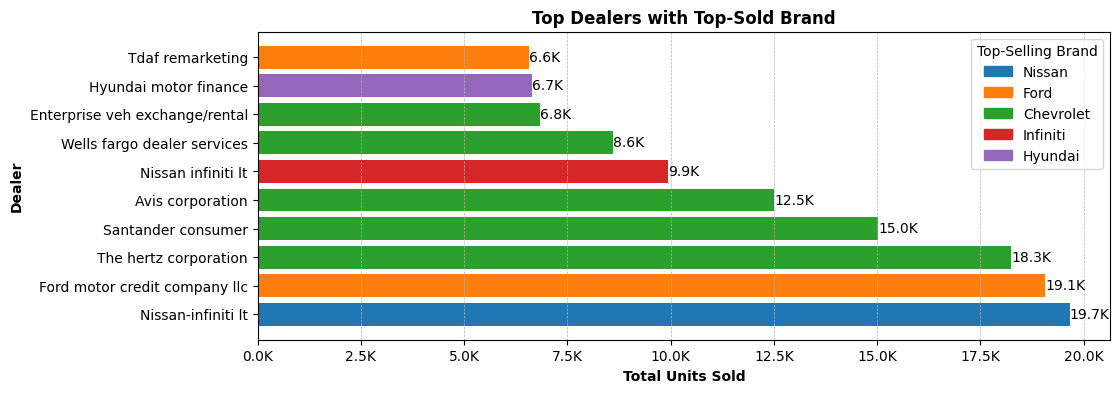

In [133]:
# Graph

plt.figure(figsize = (11, 4))

y_axis = top_10_seller["seller"].str.capitalize()
x_axis = top_10_seller["units_sold"]

companies = seller_top_make["make"].unique()

colors = plt.cm.tab10(range(len(companies)))
color_map = dict(zip(companies, colors))
bar_colors = seller_top_make["make"].map(color_map)

bars = plt.barh(y_axis, x_axis, color = bar_colors)
plt.bar_label(bars, labels = [f"{x/1000:.1f}K" for x in bars.datavalues])

plt.grid(axis = "x", linewidth = 0.5, linestyle = "--")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

legend_items = [Patch(color = color_map[company], label = company.capitalize()) for company in color_map]

plt.legend(handles = legend_items, title = "Top-Selling Brand")

plt.xlabel("Total Units Sold", fontweight = "bold")
plt.ylabel("Dealer", fontweight = "bold")
plt.title("Top Dealers with Top-Sold Brand", fontweight = "bold", fontsize = 12)

plt.savefig("../charts/top_10_sellers_with_brand.png", bbox_inches = "tight")

plt.show()

In [134]:
# 16. Effect of odometer in condition

odometer_analysis = dataset[["odometer", "condition", "mmr_vs_sp_percent", "vehicle_age"]]
odometer_condition = (odometer_analysis.groupby(["condition"])["odometer"]
                      .agg('median')
                      .reset_index(name = "odometer")
                      )

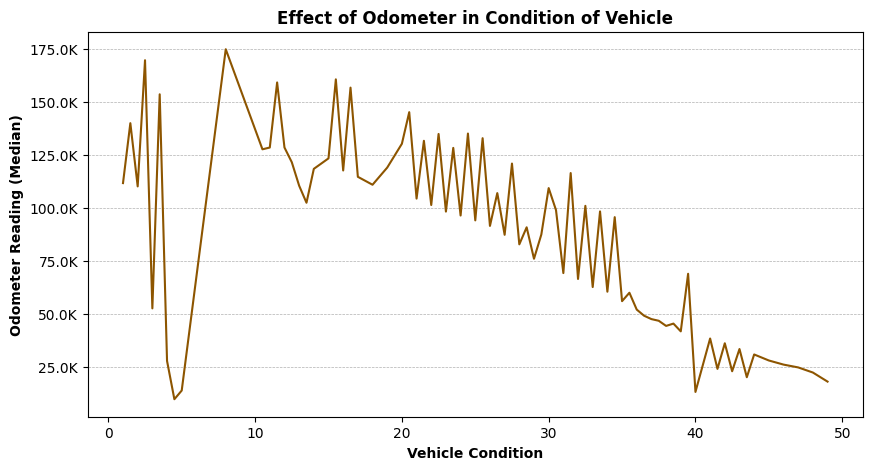

In [135]:
# Graph

plt.figure(figsize = (10, 5))

x_axis = odometer_condition["condition"]
y_axis = odometer_condition["odometer"]

plt.plot(x_axis, y_axis, color = "#8D5500")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000}K")
)

plt.grid(axis = "y", linestyle = "--", linewidth = 0.5)

plt.xlabel("Vehicle Condition", fontweight = "bold")
plt.ylabel("Odometer Reading (Median)", fontweight = "bold")
plt.title("Effect of Odometer in Condition of Vehicle", fontweight = "bold")

plt.savefig("../charts/odometer_by_condition.png" ,bbox_inches = "tight")
plt.show()

In [136]:
# 17. Top 10 body type by states

body_state_group = (dataset.groupby(["body", "state"])["vin"]
                    .agg('count')
                    .reset_index(name = "units_sold"))

body_top_state = body_state_group.loc[body_state_group.groupby(["body"])["units_sold"].idxmax()]



body_top_state = (body_top_state[body_top_state["body"].isin(top_10_body["body"])]
                  .set_index("body")
                  .reindex(top_10_body["body"])
                  .reset_index())

body_top_state


,body,state,units_sold
0,sedan,fl,38519
1,suv,fl,19076
2,hatchback,ca,4692
3,minivan,fl,4323
4,coupe,ca,3212
5,crew cab,tx,3022
6,wagon,ca,2131
7,convertible,ca,2528
8,supercrew,tx,1347
9,g sedan,ca,1821


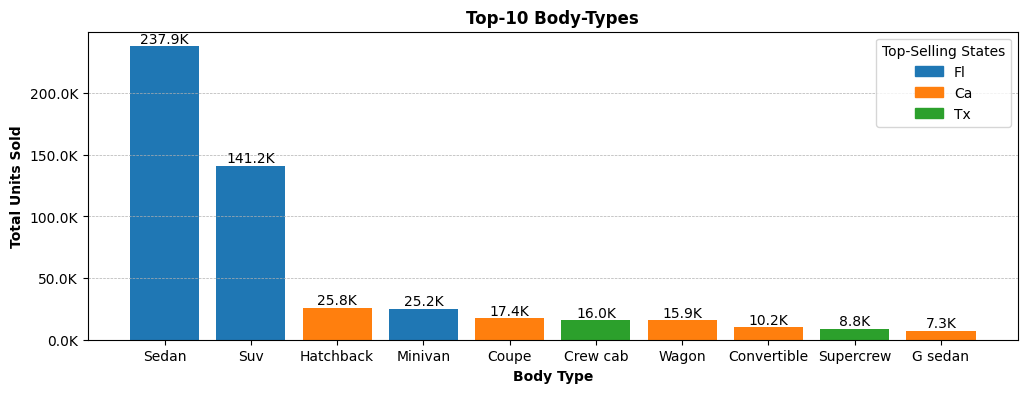

In [137]:
# Graph

plt.figure(figsize = (12, 4))

x_axis = top_10_body["body"].str.capitalize()
y_axis = top_10_body["units_sold"]

states = body_top_state["state"].unique()

colors = plt.cm.tab10(range(len(states)))
color_map = dict(zip(states, colors))
color_bars = body_top_state["state"].map(color_map)

bars = plt.bar(x_axis, y_axis, color = color_bars)

plt.bar_label(bars, labels = [f"{x/1000:.1f}K" for x in bars.datavalues])

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.grid(axis = "y", linewidth = 0.5, linestyle = "--")

legend_items = [Patch(color = color_map[state], label = state.capitalize()) for state in color_map]

plt.legend(handles = legend_items, title = "Top-Selling States")
plt.xlabel("Body Type", fontweight = "bold")
plt.ylabel("Total Units Sold", fontweight = "bold")
plt.title("Top-10 Body-Types", fontweight = "bold", fontsize = 12)

plt.savefig("../charts/top_body_state.png", bbox_inches = "tight")

plt.show()

In [174]:
# 18. Top companies with least mmr-sp difference.

top_make_mmr_diff_abs = (dataset.groupby(["make"])["mmr_vs_sp_percent"]
                         .agg('median')
                         .reset_index(name = "mmr_diff")
                         )

top_make_mmr_diff_abs = top_make_mmr_diff_abs.assign(sign = np.where(top_make_mmr_diff_abs["mmr_diff"] >= 0, "below MMR", "above MMR"),
                                             abs_diff = top_make_mmr_diff_abs["mmr_diff"].abs())

top_make_mmr_diff_abs = (top_make_mmr_diff_abs.sort_values(by = "abs_diff", ascending = False)
                     .head(10))

top_make_mmr_diff_negative = (dataset.groupby(["make"])["mmr_vs_sp_percent"]
                              .agg('median')
                              .sort_values()
                              .head(10)
                              .reset_index(name = "mmr_diff")
                              )

top_make_mmr_diff_positive = (dataset.groupby(["make"])["mmr_vs_sp_percent"]
                              .agg('median')
                              .sort_values(ascending = False)
                              .head(10)
                              .reset_index(name = "mmr_diff")
                              )

top_make_mmr_diff_abs

,make,mmr_diff,sign,abs_diff
1,airstream,140.68,below MMR,140.68
13,dot,-41.18,above MMR,41.18
20,geo,-20.00,above MMR,20.00
18,ford tk,-19.42,above MMR,19.42
46,oldsmobile,-14.29,above MMR,14.29
12,dodge tk,-12.00,above MMR,12.00
27,isuzu,-7.69,above MMR,7.69
10,daewoo,-6.84,above MMR,6.84
48,pontiac,-5.56,above MMR,5.56
40,mercedes-b,-5.38,above MMR,5.38


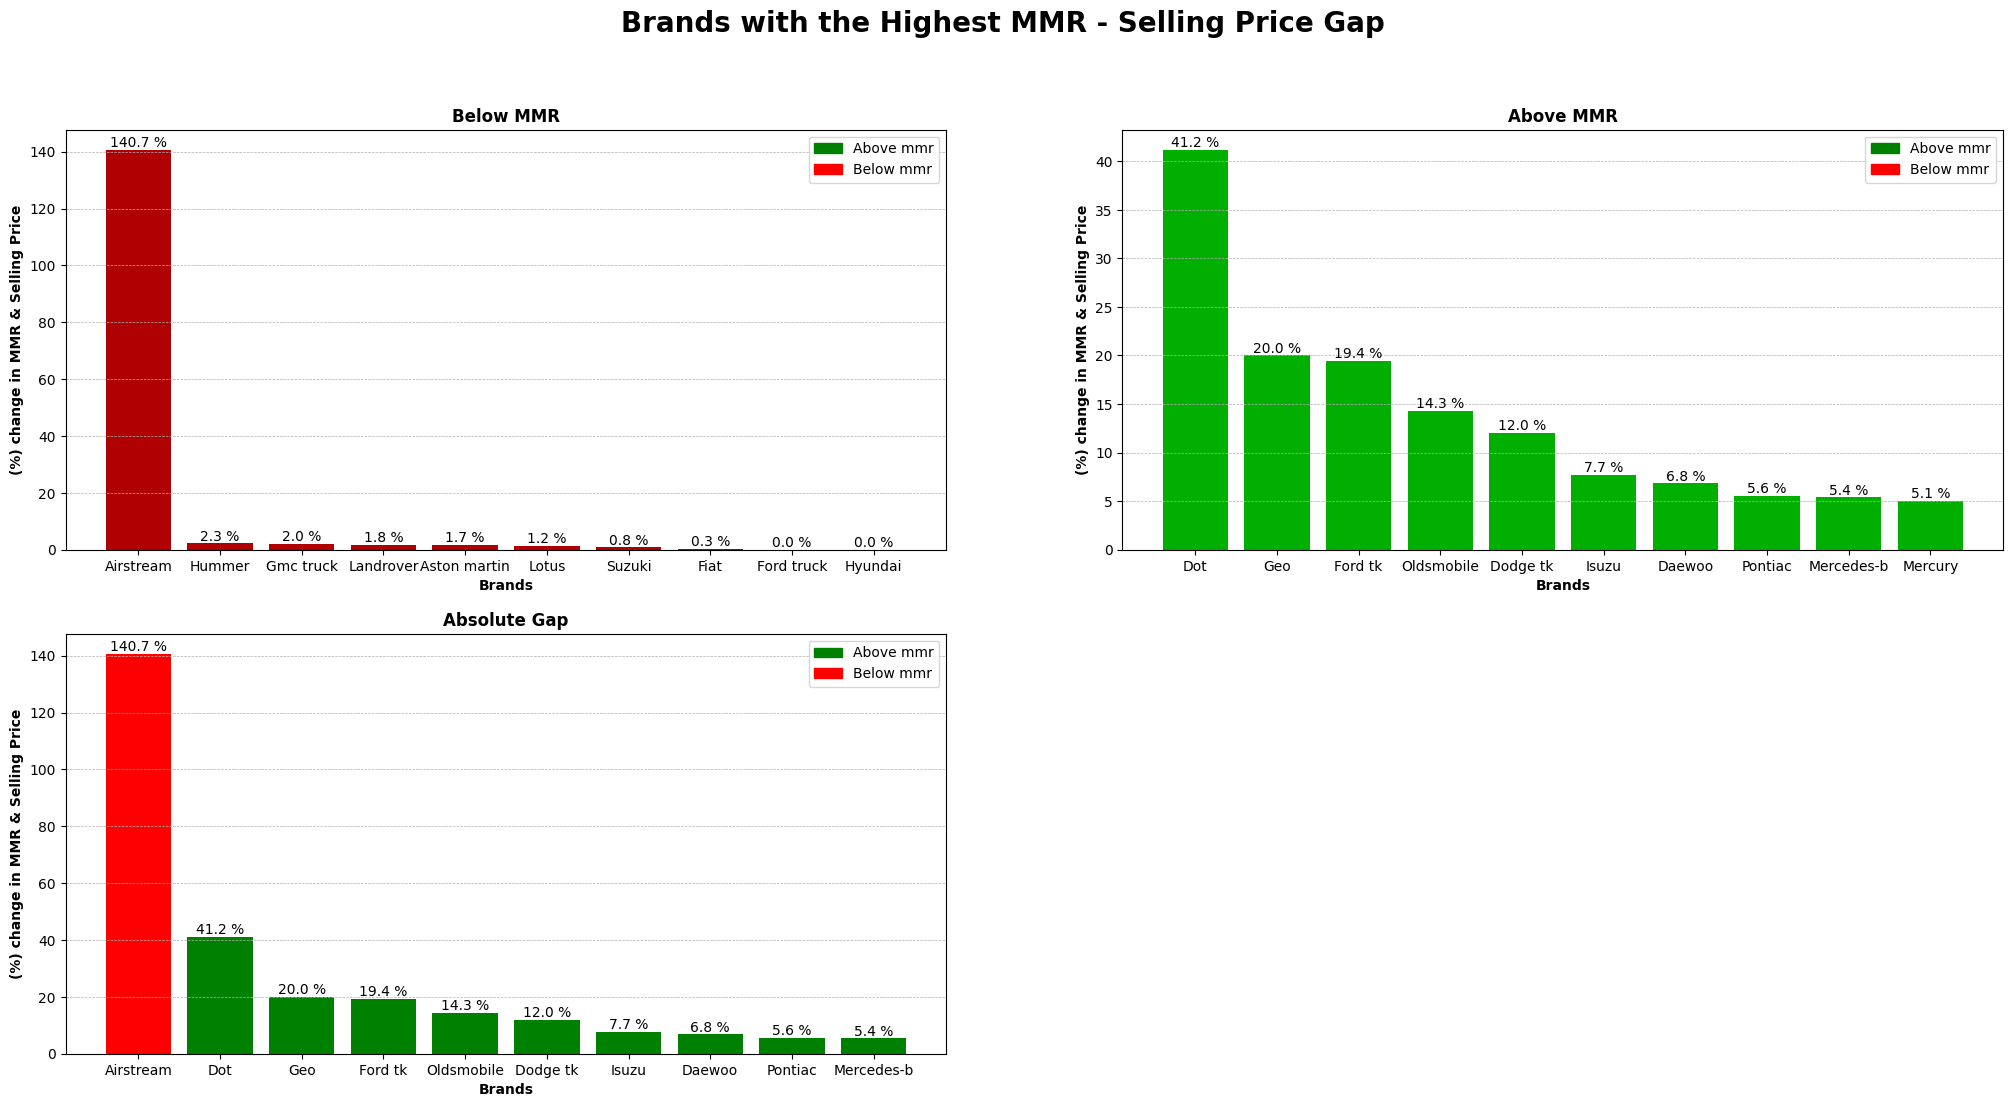

In [197]:
# Graph

plt.figure(figsize = (25, 12))

# G-1: Below MMR

plt.subplot(2, 2, 1)

x_axis = top_make_mmr_diff_positive["make"].str.capitalize()
y_axis = top_make_mmr_diff_positive["mmr_diff"].abs()

bars = plt.bar(x_axis, y_axis, color = "#af0101")
plt.bar_label(bars, labels = [f"{x:.1f} %" for x in bars.datavalues])
plt.grid(axis = "y", linewidth = 0.5, linestyle = "--")

legend_items = [Patch(color = color_map[sign], label = sign.capitalize()) for sign in color_map]
plt.legend(handles = legend_items)

plt.xlabel("Brands", fontweight = "bold")
plt.ylabel("(%) change in MMR & Selling Price", fontweight = "bold")
plt.title("Below MMR", fontweight = "bold")

# G-2 : Above MMR

plt.subplot(2, 2, 2)

x_axis = top_make_mmr_diff_negative["make"].str.capitalize()
y_axis = top_make_mmr_diff_negative["mmr_diff"].abs()

bars = plt.bar(x_axis, y_axis, color = "#01af01")
plt.bar_label(bars, labels = [f"{x:.1f} %" for x in bars.datavalues])
plt.grid(axis = "y", linewidth = 0.5, linestyle = "--")

legend_items = [Patch(color = color_map[sign], label = sign.capitalize()) for sign in color_map]
plt.legend(handles = legend_items)

plt.xlabel("Brands", fontweight = "bold")
plt.ylabel("(%) change in MMR & Selling Price", fontweight = "bold")
plt.title("Above MMR", fontweight = "bold")

# G-3: Absolute Gap

plt.subplot(2, 2, 3)

x_axis = top_make_mmr_diff_abs["make"].str.capitalize()
y_axis = top_make_mmr_diff_abs["abs_diff"]

color_map = {"above MMR" : "green", "below MMR" : "red"}
color_bars = top_make_mmr_diff_abs["sign"].map(color_map)

bars = plt.bar(x_axis, y_axis, color = color_bars)

plt.bar_label(bars, labels = [f"{x:.1f} %" for x in bars.datavalues])
plt.grid(axis = "y", linewidth = 0.5, linestyle = "--")

legend_items = [Patch(color = color_map[sign], label = sign.capitalize()) for sign in color_map]
plt.legend(handles = legend_items)

plt.xlabel("Brands", fontweight = "bold")
plt.ylabel("(%) change in MMR & Selling Price", fontweight = "bold")
plt.title("Absolute Gap", fontweight = "bold")

plt.suptitle("Brands with the Highest MMR - Selling Price Gap", fontweight = "bold", fontsize = 20)
plt.savefig("../charts/make_vs_mmr_diff.png", bbox_inches = "tight")

plt.show()

In [ ]:
# 19. Top sellers with Max mmr-sp difference.

base_seller_mmr_diff = (dataset.groupby(["seller"])["mmr_vs_sp_percent"]
                       .agg('median')
                       .reset_index(name = "mmr_diff"))

base_seller_mmr_diff = (base_seller_mmr_diff.assign(abs_diff = base_seller_mmr_diff["mmr_diff"].abs(),
                                                    sign = np.where(base_seller_mmr_diff["mmr_diff"] >= 0, "Below MMR", "Above MMR"))
                       )

top_seller_mmr_diff = base_seller_mmr_diff.sort_values(by = "abs_diff", ascending = False).head(10)
top_seller_mmr_diff_above = base_seller_mmr_diff.sort_values(by = "mmr_diff").head(10)
top_seller_mmr_diff_below = base_seller_mmr_diff.sort_values(by = "mmr_diff", ascending = False).head(10)

top_seller_mmr_diff_above




,seller,mmr_diff,abs_diff,sign
6214,hub hyundai west,-96.68,96.68,Above MMR
8188,mendocino auto sales/repair center inc,-95.21,95.21,Above MMR
8456,millenium & associates inc,-94.63,94.63,Above MMR
11515,sfim auto sales & services,-93.49,93.49,Above MMR
10547,regional finance corp/conway,-91.89,91.89,Above MMR
7665,low country credit,-91.77,91.77,Above MMR
3048,citizens finance/loves park,-90.21,90.21,Above MMR
7847,makarios auto sales llc,-90.06,90.06,Above MMR
4531,euro wheels,-88.84,88.84,Above MMR
12464,three some auto sales,-88.68,88.68,Above MMR


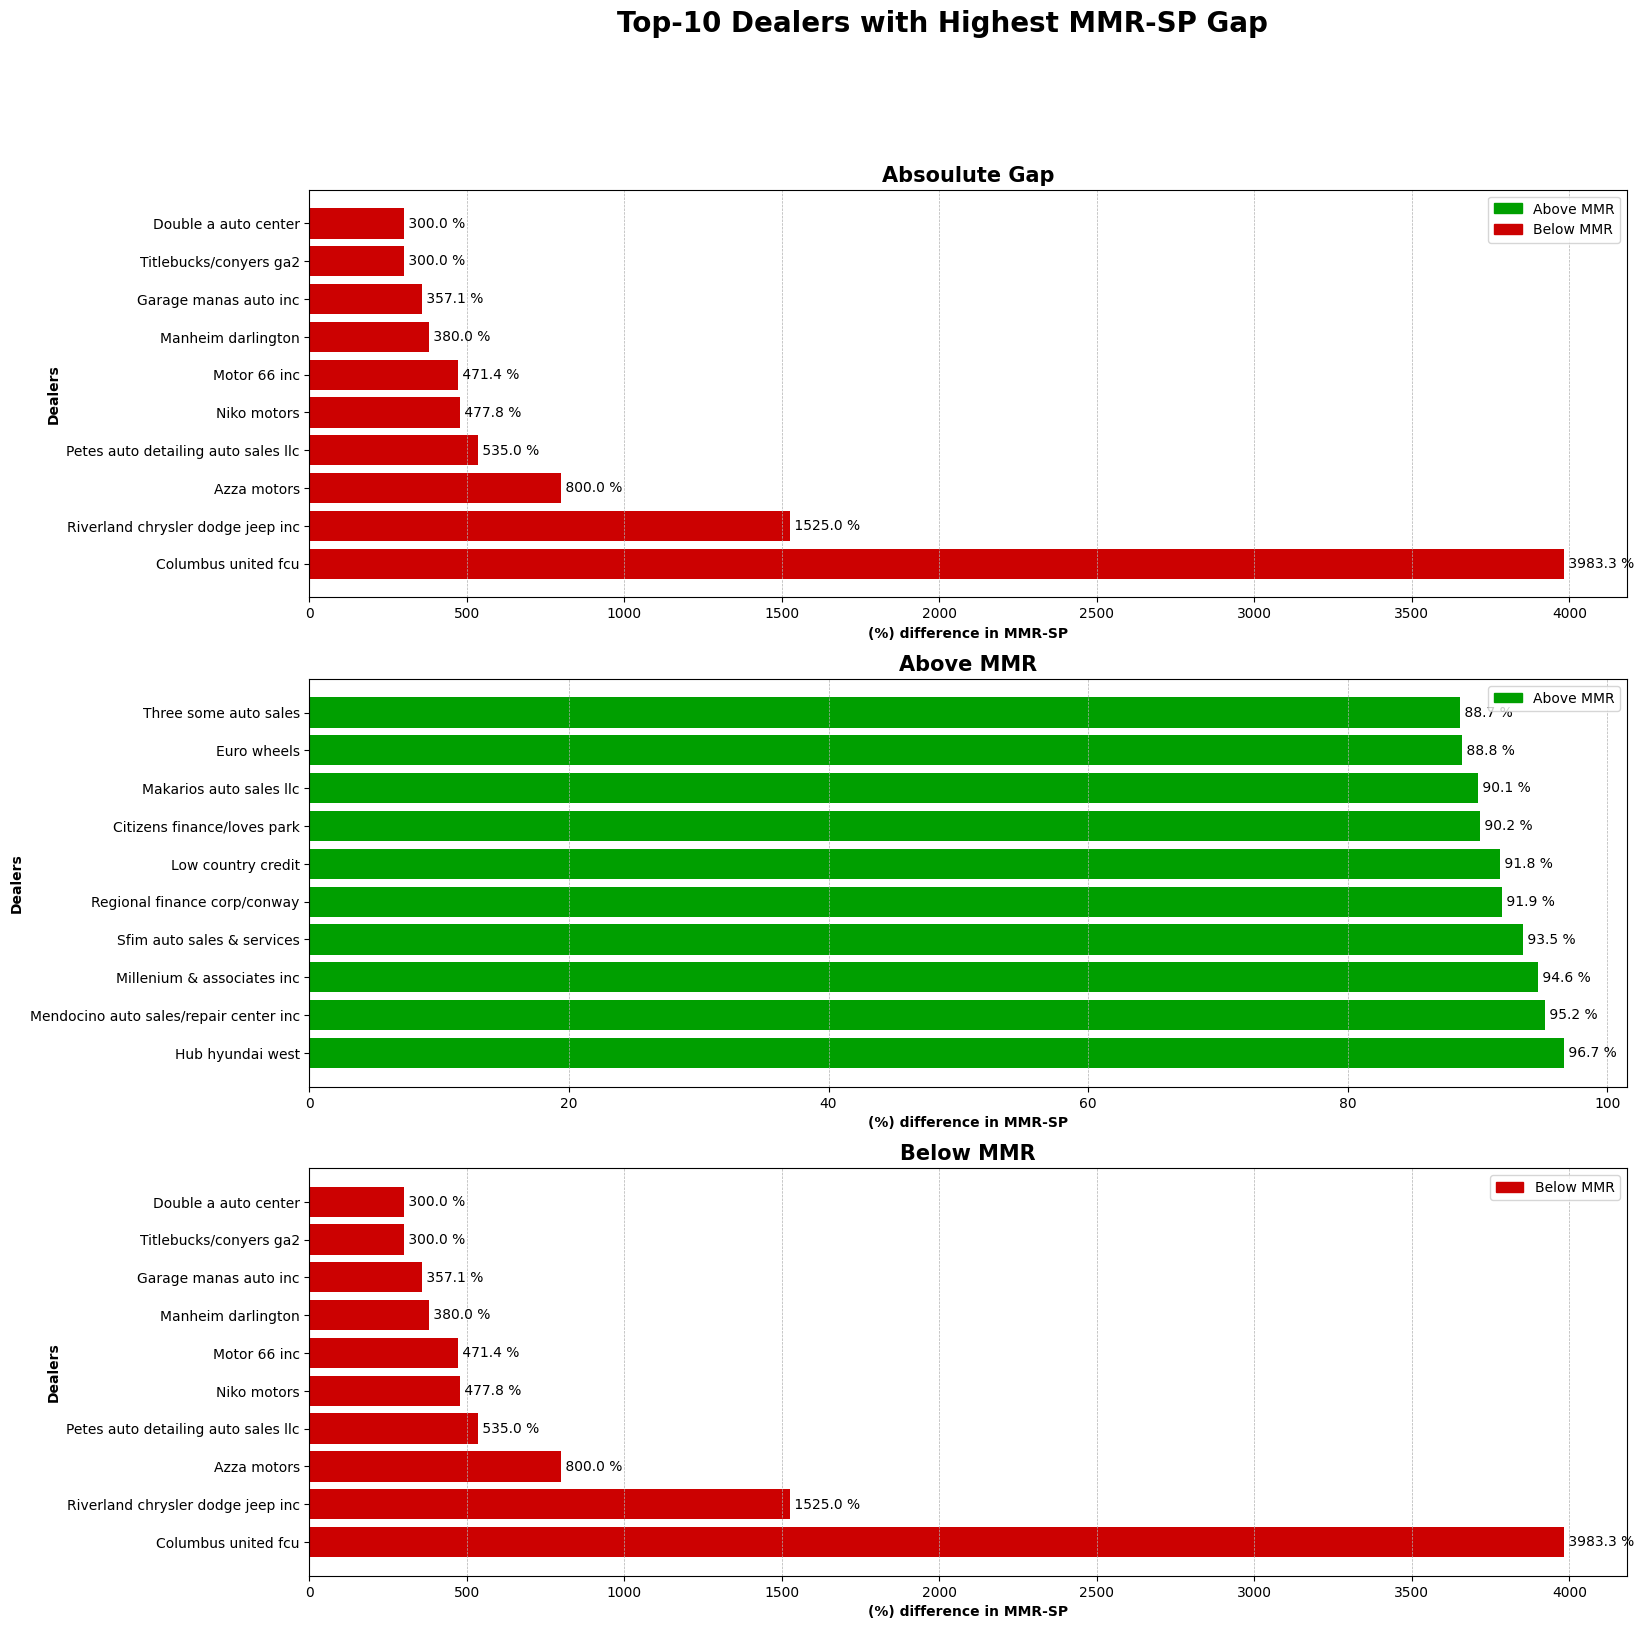

In [278]:
# Graph

plt.figure(figsize = (17, 18))

plt.subplot(3, 1, 1)

y_axis = top_seller_mmr_diff["seller"].str.capitalize()
x_axis = top_seller_mmr_diff["abs_diff"]

color_map = {"Above MMR" : "#009f00", "Below MMR" : "#cc0101"}
bar_colors = top_seller_mmr_diff["sign"].map(color_map)

bars = plt.barh(y_axis, x_axis, color = bar_colors)

plt.bar_label(bars, labels = [f" {x:.1f} %" for x in bars.datavalues])

plt.grid(axis = "x", linestyle = "--", linewidth = 0.5)

legend_items = [Patch(color = color_map[sign], label = sign) for sign in color_map]
plt.legend(handles = legend_items)

plt.xlabel("(%) difference in MMR-SP", fontweight = "bold")
plt.ylabel("Dealers", fontweight = "bold")
plt.title("Absoulute Gap", fontweight = "bold", fontsize = 15)

# G-2: Above MMR

plt.subplot(3, 1, 2)

y_axis = top_seller_mmr_diff_above["seller"].str.capitalize()
x_axis = top_seller_mmr_diff_above["abs_diff"]

bars = plt.barh(y_axis, x_axis, color = "#009f00")

plt.bar_label(bars, labels = [f" {x:.1f} %" for x in bars.datavalues])

plt.grid(axis = "x", linestyle = "--", linewidth = 0.5)

legend_items = [Patch(color = "#009f00", label = "Above MMR")]
plt.legend(handles = legend_items)

plt.xlabel("(%) difference in MMR-SP", fontweight = "bold")
plt.ylabel("Dealers", fontweight = "bold")
plt.title("Above MMR", fontweight = "bold", fontsize = 15)

# G-3: Below MMR

plt.subplot(3, 1, 3)

y_axis = top_seller_mmr_diff_below["seller"].str.capitalize()
x_axis = top_seller_mmr_diff_below["abs_diff"]

bars = plt.barh(y_axis, x_axis, color = "#cc0101")

plt.bar_label(bars, labels = [f" {x:.1f} %" for x in bars.datavalues])

plt.grid(axis = "x", linestyle = "--", linewidth = 0.5)

legend_items = [Patch(color = "#cc0101", label = "Below MMR")]
plt.legend(handles = legend_items)

plt.xlabel("(%) difference in MMR-SP", fontweight = "bold")
plt.ylabel("Dealers", fontweight = "bold")
plt.title("Below MMR", fontweight = "bold", fontsize = 15)

plt.suptitle("Top-10 Dealers with Highest MMR-SP Gap ", fontsize = 20, fontweight = "bold")

plt.savefig("../charts/dealers_with_max_mmr_diff.png", bbox_inches = "tight")
plt.show()